# Yelp Review Prediction - 30D1Y COVID (Template Import)

This notebook imports functions from `prediction_template.ipynb` and runs the full pipeline with COVID settings.

In [1]:
from pathlib import Path

%run ./prediction_template.ipynb

PROCESSED_DIR = Path("./processed_data")
COHORT_YEAR = 2020 
EARLY_WINDOW_DAYS = 30 * 2
FUTURE_WINDOW_END_DAY = 365
MIN_EARLY_REVIEWS = 5
MIN_FUTURE_REVIEWS = 15
PERIOD = "COVID"
FEATURE_FILE = "review_features.csv"

Sanity check report
Rows: 698
Columns: 16
Features: 14
Missing features: 0
Duplicate business_id: 0
Missing target values: 0
Missing feature values: 0
Target summary:
count    698.000000
mean       4.141090
std        0.647702
min        1.000000
25%        3.850155
50%        4.291667
75%        4.607838
max        5.000000
dtype: float64
Regression results
               model       mae      rmse        r2  n_train  n_test  \
0  linear_regression  0.323470  0.421912  0.449230      558     140   
1              ridge  0.323860  0.422001  0.448997      558     140   
2      random_forest  0.339307  0.441998  0.395540      558     140   
3            xgboost  0.364081  0.475886  0.299300      558     140   
4      baseline_mean  0.453158  0.571093 -0.009112      558     140   

   n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used  
0          14     0.332462    0.019844    0.546299   0.036110              5  
1          14     0.332610    0.019814    0.546556   0

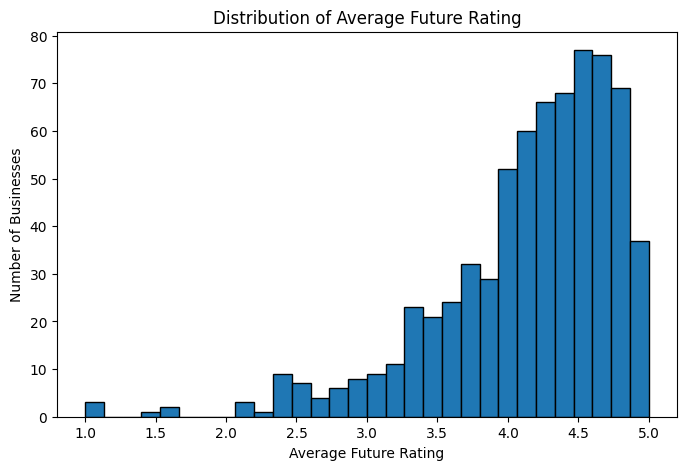

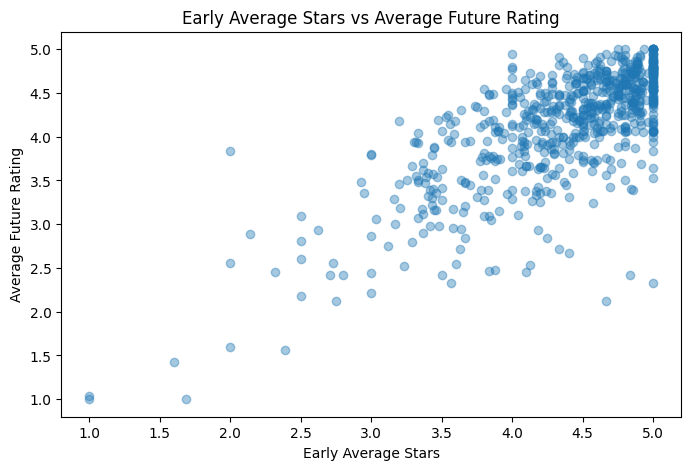

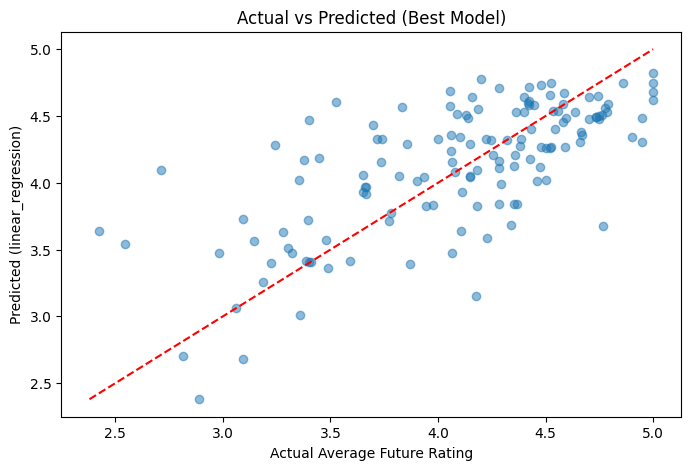

Best model: linear_regression
model            linear_regression
mae                        0.32347
rmse                      0.421912
r2                         0.44923
n_train                        558
n_test                         140
n_features                      14
cv_mae_mean               0.332462
cv_mae_std                0.019844
cv_r2_mean                0.546299
cv_r2_std                  0.03611
cv_folds_used                    5
Name: 0, dtype: object


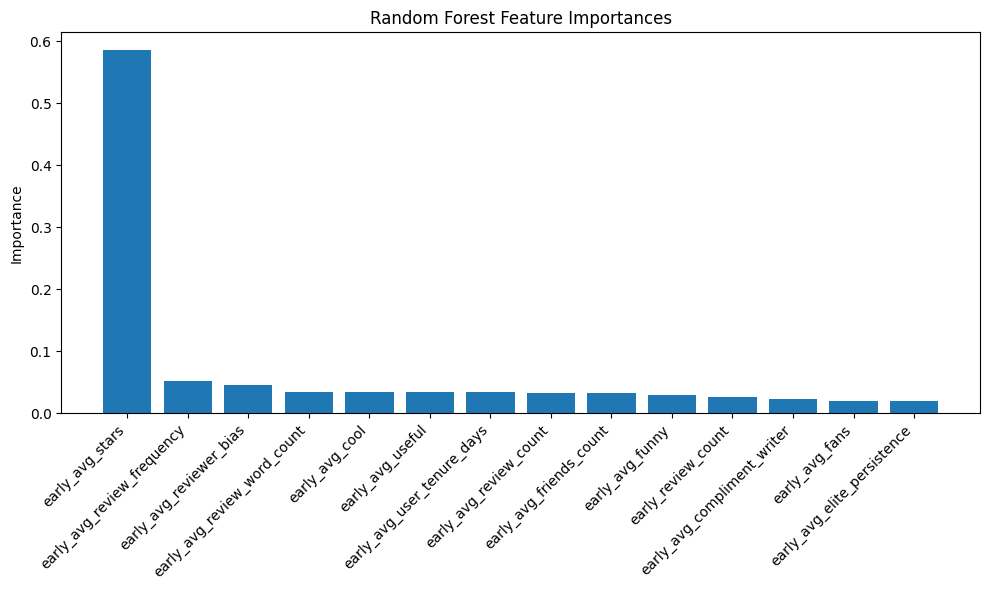

Top correlations with average_future_rating:


,feature,corr
0,early_avg_stars,0.736703
1,early_avg_reviewer_bias,0.614009
2,early_avg_review_word_count,-0.221098
3,early_avg_user_tenure_days,0.114997
4,early_avg_cool,0.114199
5,early_avg_fans,0.099812
6,early_avg_friends_count,0.083810
7,early_avg_compliment_writer,0.078489
8,early_review_count,-0.072275
9,early_avg_elite_persistence,0.068026


,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
1,-1YvpVvnnLrTZ0zjtUYPXA,3.300000,3.700000,0.200000,0.600000,97.100000,4.600000,152.000000,5.150000,-0.619500,2101.050000,1.450000,126.350000,43.700000,20,3.937500
7,-2wh7NTLkWEgsrLJvilnFQ,4.666667,2.200000,0.400000,1.533333,232.133333,26.200000,74.000000,19.933333,0.536000,2109.266667,0.600000,75.800000,78.200000,15,4.347826
8,-3-6BB10tIWNKGEF0Es2BA,3.954545,2.681818,0.363636,1.000000,46.863636,3.863636,56.727273,2.272727,0.095000,1742.272727,0.909091,112.272727,28.772727,22,4.284211
17,-BdYhP-12elmFV7oB1iv4A,5.000000,0.857143,0.142857,0.428571,27.285714,1.142857,58.142857,1.142857,0.477143,1938.000000,0.285714,76.428571,5.571429,7,4.826087
26,-FPHImCrh555pkxNetpreA,4.562500,2.062500,0.125000,1.000000,167.250000,15.937500,173.375000,16.187500,0.256875,1746.125000,1.875000,144.562500,65.937500,16,4.324324


In [2]:
pipeline_output = run_prediction_pipeline(
    processed_dir=PROCESSED_DIR,
    cohort_year=COHORT_YEAR,
    early_window_days=EARLY_WINDOW_DAYS,
    future_window_end_day=FUTURE_WINDOW_END_DAY,
    period=PERIOD,
    min_early_reviews=MIN_EARLY_REVIEWS,
    min_future_reviews=MIN_FUTURE_REVIEWS,
    feature_file=FEATURE_FILE,
)

model_df = pipeline_output["model_df"]
feature_cols = pipeline_output["feature_cols"]
target_col = pipeline_output["target_col"]

print("Model dataset shape:", model_df.shape)
print("Target column:", target_col)
print("Number of features:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])
print("Sanity report:", pipeline_output["sanity_report"])
print("Regression summary:")
print(pipeline_output["regression_report"]["results_df"])

output_dir = PROCESSED_DIR / "modeling_tables"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"business_level_{EARLY_WINDOW_DAYS}D_{FUTURE_WINDOW_END_DAY}D_{PERIOD}.csv"
model_df.to_csv(output_path, index=False, float_format="%.4f")
print("Saved modeling table to:", output_path.resolve())

results_package = generate_results_package(
    pipeline_output=pipeline_output,
    target_col=target_col,
    top_n_correlations=15,
    show_plots=True,
)

print("Top correlations with average_future_rating:")
display(results_package["correlation_table"])

model_df.head()

In [3]:
# Exploratory Tables and Graphs
# Summary stats, head, and missing values
import pandas as pd

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSummary statistics:")
print(model_df.describe())

print("\nMissing values per column:")
print(model_df.isnull().sum())

print("\nFirst 5 rows:")
model_df.head()

Model dataset shape: (698, 16)

Columns:
['business_id', 'early_avg_stars', 'early_avg_useful', 'early_avg_funny', 'early_avg_cool', 'early_avg_review_count', 'early_avg_fans', 'early_avg_friends_count', 'early_avg_compliment_writer', 'early_avg_reviewer_bias', 'early_avg_user_tenure_days', 'early_avg_elite_persistence', 'early_avg_review_word_count', 'early_avg_review_frequency', 'early_review_count', 'average_future_rating']

Summary statistics:
       early_avg_stars  early_avg_useful  early_avg_funny  early_avg_cool  \
count       698.000000        698.000000       698.000000      698.000000   
mean          4.365699          1.736968         0.401578        0.985609   
std           0.622975          1.572630         0.686025        1.337272   
min           1.000000          0.000000         0.000000        0.000000   
25%           4.087945          0.818182         0.071429        0.250000   
50%           4.506098          1.333333         0.204545        0.625000   
75%      

,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
1,-1YvpVvnnLrTZ0zjtUYPXA,3.300000,3.700000,0.200000,0.600000,97.100000,4.600000,152.000000,5.150000,-0.619500,2101.050000,1.450000,126.350000,43.700000,20,3.937500
7,-2wh7NTLkWEgsrLJvilnFQ,4.666667,2.200000,0.400000,1.533333,232.133333,26.200000,74.000000,19.933333,0.536000,2109.266667,0.600000,75.800000,78.200000,15,4.347826
8,-3-6BB10tIWNKGEF0Es2BA,3.954545,2.681818,0.363636,1.000000,46.863636,3.863636,56.727273,2.272727,0.095000,1742.272727,0.909091,112.272727,28.772727,22,4.284211
17,-BdYhP-12elmFV7oB1iv4A,5.000000,0.857143,0.142857,0.428571,27.285714,1.142857,58.142857,1.142857,0.477143,1938.000000,0.285714,76.428571,5.571429,7,4.826087
26,-FPHImCrh555pkxNetpreA,4.562500,2.062500,0.125000,1.000000,167.250000,15.937500,173.375000,16.187500,0.256875,1746.125000,1.875000,144.562500,65.937500,16,4.324324


In [4]:
# Correlation with target: top features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if "average_future_rating" in numeric_cols:
    corr_series = model_df[numeric_cols].corr()["average_future_rating"].drop("average_future_rating")
    corr_top = corr_series.abs().sort_values(ascending=False).head(15)
    print("Top correlations with average_future_rating (by absolute value):")
    display(pd.DataFrame({"feature": corr_top.index, "corr": corr_top.values}))
else:
    print("average_future_rating not in numeric columns; skipping correlation summary.")

Top correlations with average_future_rating (by absolute value):


,feature,corr
0,early_avg_stars,0.736703
1,early_avg_reviewer_bias,0.614009
2,early_avg_review_word_count,0.221098
3,early_avg_user_tenure_days,0.114997
4,early_avg_cool,0.114199
5,early_avg_fans,0.099812
6,early_avg_friends_count,0.083810
7,early_avg_compliment_writer,0.078489
8,early_review_count,0.072275
9,early_avg_elite_persistence,0.068026


ALL MODEL RESULTS
               model       mae      rmse        r2  n_train  n_test  n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used
0  linear_regression  0.323470  0.421912  0.449230      558     140          14     0.332462    0.019844    0.546299   0.036110              5
1              ridge  0.323860  0.422001  0.448997      558     140          14     0.332610    0.019814    0.546556   0.035783              5
2      random_forest  0.339307  0.441998  0.395540      558     140          14     0.350317    0.018882    0.490700   0.057556              5
3            xgboost  0.364081  0.475886  0.299300      558     140          14     0.360150    0.027978    0.470171   0.030614              5
4      baseline_mean  0.453158  0.571093 -0.009112      558     140          14     0.496349    0.043325   -0.017478   0.016695              5



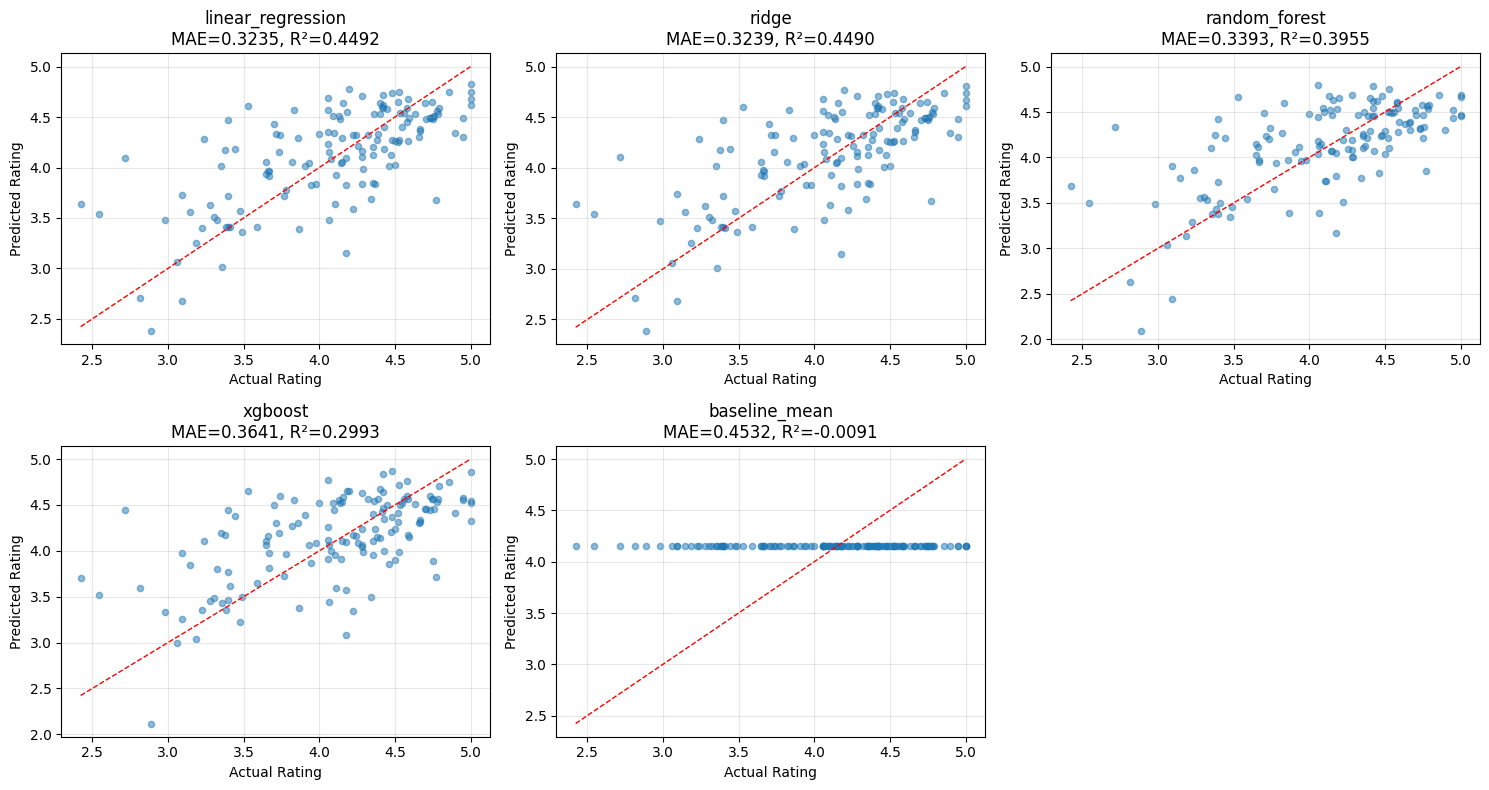

In [5]:
# Model Results: All models with predicted vs actual plots
import numpy as np

results_df = pipeline_output["regression_report"]["results_df"]
predictions_df = pipeline_output["regression_report"]["predictions_df"].copy()

print("=" * 80)
print("ALL MODEL RESULTS")
print("=" * 80)
print(results_df.to_string())
print()

y_true = predictions_df["average_future_rating"].values
min_val = float(y_true.min())
max_val = float(y_true.max())

# Plot predicted vs actual for each model
num_models = len(results_df)
n_cols = 3
n_rows = (num_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to 1D array for easier iteration

for idx, (_, row) in enumerate(results_df.iterrows()):
    model_name = row["model"]
    mae = row["mae"]
    r2 = row["r2"]
    
    # Get predictions for this model
    if model_name == "baseline_mean":
        pred_col = "pred_baseline_mean"
    else:
        pred_col = f"pred_{model_name}"
    
    if pred_col not in predictions_df.columns:
        print(f"Warning: {pred_col} not found in predictions_df")
        continue
    
    y_pred = predictions_df[pred_col].values
    
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", linewidth=1)
    ax.set_xlabel("Actual Rating")
    ax.set_ylabel("Predicted Rating")
    ax.set_title(f"{model_name}\nMAE={mae:.4f}, R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


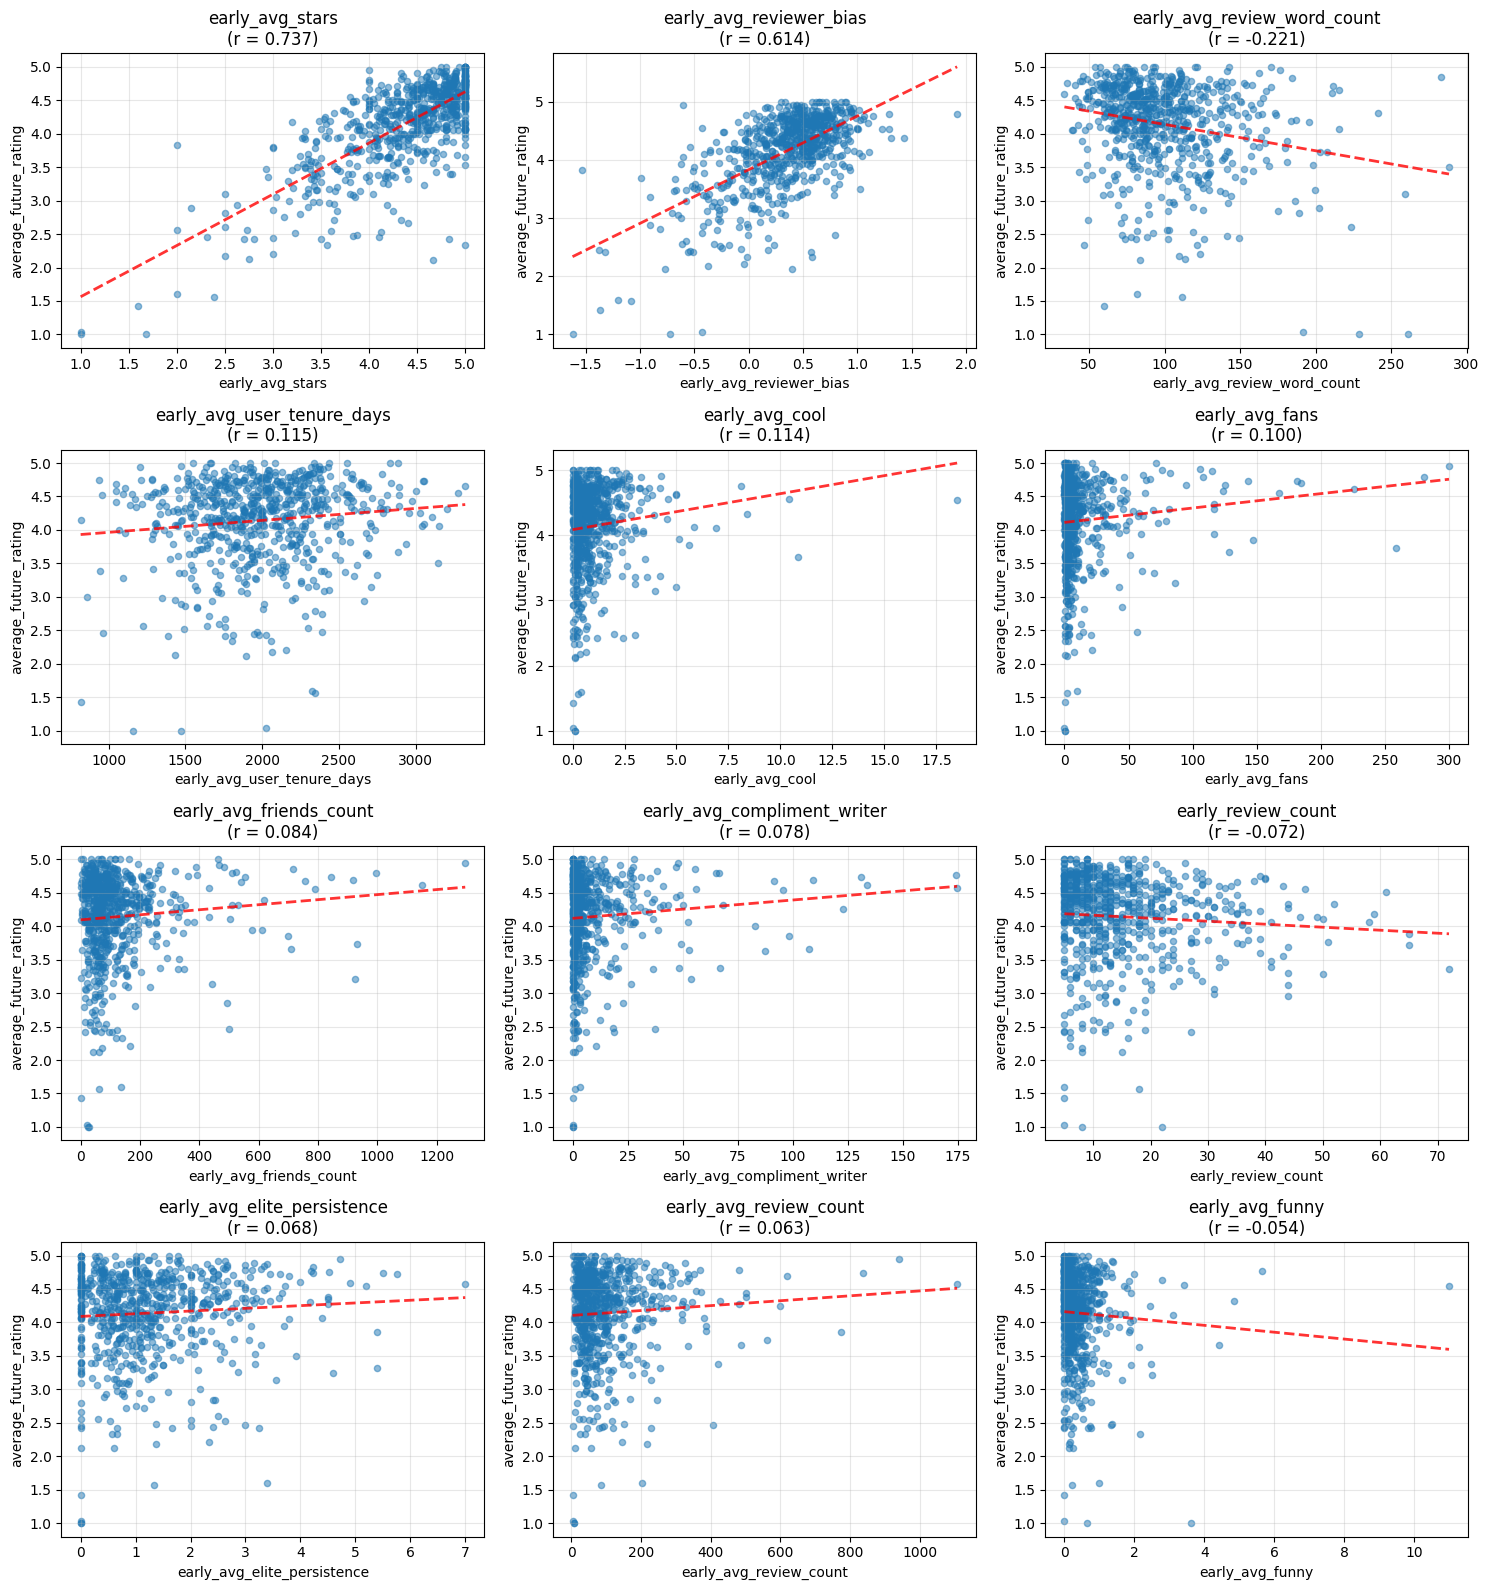

In [6]:
# Top Features vs Target Relationships
from scipy import stats

# Get top correlated features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if target_col in numeric_cols:
    corr_with_target = model_df[numeric_cols].corr()[target_col].drop(target_col)
    top_features = corr_with_target.abs().sort_values(ascending=False).head(12).index.tolist()
    
    # Create scatter plots for top features
    n_features = len(top_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for idx, feature in enumerate(top_features):
        ax = axes[idx]
        
        # Scatter plot
        ax.scatter(model_df[feature], model_df[target_col], alpha=0.5, s=20)
        
        # Add trend line
        z = np.polyfit(model_df[feature].dropna(), model_df[target_col].loc[model_df[feature].notna()], 1)
        p = np.poly1d(z)
        x_line = np.linspace(model_df[feature].min(), model_df[feature].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Calculate correlation
        corr_coef = corr_with_target[feature]
        
        ax.set_xlabel(feature)
        ax.set_ylabel(target_col)
        ax.set_title(f"{feature}\n(r = {corr_coef:.3f})")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"{target_col} not in numeric columns; skipping feature vs target analysis.")
